# Handling model settings and observations from OGGM v1.7 onwards

This tutorial explains how model settings and observations are handled in OGGM from v1.7 onwards. It is intended for users who want to run multiple model simulations within a single glacier directory (`gdir`), for example for sensitivity studies or ensemble approaches (e.g. running the same workflow with different parameter values or perturbed observations).

**Prerequisites:** familiarity with the basic OGGM workflow and the concept of
`entity_task`s (see [this introductory tutorial](../10minutes/preprocessed_directories.ipynb)).

**What you will learn:**
- How `settings.yml` and `observations.yml` work and why they were introduced
- How to create custom settings and observations files
- How to run a [simple sensitivity study by perturbing mass balance parameters](#a-simple-sensitivity-study)
- How to [combine settings and observations perturbations in a full OGGM workflow](#combining-settings-with-observations-sensitivity)
- How to [perturb global parameters such as ice density](#advanced-sensitivity-study:-perturbing-global-parameters-(ice-density))

## How the new system works

Before v1.7, model parameters and settings were scattered across several locations: global settings and first-guess values were stored in `cfg.PARAMS`, mass balance parameters in `mb_calib.json`, and dynamic parameters in `gdir.get_diagnostics()`. Observations used during calibration were similarly spread across different files and had no central storage. Starting with v1.7, OGGM centralizes this through two new files per glacier directory:

- **`settings.yml`**: stores glacier-specific parameter values. Global
  parameters (shared across all glaciers) remain in `cfg.PARAMS`, but you
  can access both through the same interface without needing to know where a
  parameter is actually stored.
- **`observations.yml`**: stores the observations used during calibration or
  assimilation (e.g. reference mass balance, reference volume).

To make this easy to use in practice, all OGGM tasks accept a `settings_filesuffix` keyword argument. Tasks that use observations also accept `observations_filesuffix`. By switching these suffixes, you can run the same task with different parameter sets or different observations. This is the foundation of the sensitivity workflows shown in this tutorial.

The new system is designed to be **backwards compatible**: if no v1.7 settings files exist, OGGM falls back to the pre-v1.7 locations automatically.

## Exploring `settings.yml`

In [1]:
# Imports
import logging  # needed for defining custom entity tasks

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from oggm import cfg, utils, workflow, DEFAULT_BASE_URL, tasks

In [2]:
# set up oggm with two test glaciers
cfg.initialize()

# use multiprocessing
cfg.PARAMS['use_multiprocessing'] = True

# define a temporary working directory
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='new_settings_handling', reset=True)

# set up test gdirs
rgi_ids = ['RGI60-11.00897',  # Hintereisferner
           'RGI60-11.01450',  # Aletsch Glacier
          ]

gdirs = workflow.init_glacier_directories(
    rgi_ids,  # which glaciers?
    prepro_base_url=DEFAULT_BASE_URL, # where to fetch the data?
    from_prepro_level=4,  # what kind of data?
    prepro_border=80  # how big of a map?
)

2026-04-03 09:53:41: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-04-03 09:53:41: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-04-03 09:53:41: oggm.cfg: Multiprocessing: using all available processors (N=8)
2026-04-03 09:53:41: oggm.cfg: Multiprocessing switched ON after user settings.
2026-04-03 09:53:41: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-04-03 09:53:41: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


> **Note:** The default preprocessed glacier directories currently use v1.6.3. Once v1.7 preprocessed directories become available, this section will need to be updated accordingly.                                                                                                                                               
                                                                                                                                                                           
For now, let's look at what `settings.yml` contains for pre-v1.7 directories. We can open it using `gdir.read_yml`:

In [3]:
gdirs[0].read_yml('settings')

{'parent_filesuffix': 'cfg.PARAMS'}

There is only one entry: `'parent_filesuffix'`. This tells OGGM where to look for a setting if it is not present in the current settings file. By default it points to `cfg.PARAMS`, which was the main parameter store before v1.7.

Let's see what happens when we read a parameter using `gdir.read_settings`:

In [4]:
gdirs[0].read_settings(['ice_density'])

{'filesuffix': '', 'ice_density': 900.0}

The result is a `dict` containing the name of the settings file (`filesuffix`) and the value of the requested parameter. Since `ice_density` is not stored in `settings.yml`, OGGM followed the `parent_filesuffix` and retrieved it from    `cfg.PARAMS`. We can verify this: 

In [5]:
cfg.PARAMS['ice_density']

900.0

Let's try some other parameters:

In [6]:
gdirs[0].read_settings(['melt_f', 'inversion_glen_a'])

{'filesuffix': '',
 'melt_f': 4.906856791650656,
 'inversion_glen_a': 5.6083977640974805e-24}

In [7]:
cfg.PARAMS['melt_f'], cfg.PARAMS['inversion_glen_a']

(5.0, 2.4e-24)

The values are different from `cfg.PARAMS`. But why?

For **backwards compatibility**, OGGM checks additional locations before falling back to `cfg.PARAMS`:
- For mass balance parameters, it first checks `mb_calib.json`
- For dynamic parameters, it first checks `gdir.get_diagnostics()`
    
Only if a parameter cannot be found in any of those places does OGGM raise an error. We can confirm this fallback behaviour:

In [8]:
(gdirs[0].read_json('mb_calib')['melt_f'],
 gdirs[0].get_diagnostics()['inversion_glen_a'])

(4.906856791650656, 5.6083977640974805e-24)

These match the values returned by `gdir.read_settings`, confirming that OGGM correctly falls back to the pre-v1.7 storage locations.

> **Key point:** `gdir.read_settings` always tries to return the same default values as would have been used before v1.7, so existing workflows continue to work without modification (we hope).

Now let's see how to create a custom settings file using `gdir.create_new_settings`:

In [9]:
test_filesuffix = '_test'
gdirs[0].create_new_settings(filesuffix=test_filesuffix,
                             data={
                                 'melt_f': 5.5,
                             },
                             parent_filesuffix='',
                             # if the settings file already exists and this is False, you will get an error;
                             # if True and the file already exists, the new data is added to it
                             ignore_existing=True, 
                             # if a parameter already exists, force overwrite it;
                             # otherwise an error is raised to prevent unnoticed parameter changes
                             overwrite=True,  
                            )

You pass new parameter values as a `dict`. Setting `overwrite=True` allows overwriting parameters that are already present in the file.

Notice that we set `parent_filesuffix` to the default `settings.yml` (no suffix). This creates a **nested lookup chain**: when reading a parameter from `settings_test.yml`, OGGM first checks `settings_test.yml`, then `settings.yml`, and finally `cfg.PARAMS`. This hierarchy means you only need to store the parameters you actually want to change.

In [10]:
gdirs[0].read_settings(['melt_f', 'inversion_glen_a', 'ice_density'],
                       filesuffix=test_filesuffix
                      )

{'filesuffix': '_test',
 'melt_f': 5.5,
 'inversion_glen_a': 5.6083977640974805e-24,
 'ice_density': 900.0}

You can also call `read_settings` without a list of keys to inspect all currently available parameters:

In [11]:
gdirs[0].read_settings(filesuffix=test_filesuffix)

{'filesuffix': '_test', 'melt_f': 5.5, 'parent_filesuffix': ''}

Now that we understand how `settings.yml` works, let's use it to run a simple sensitivity study. 

## A simple sensitivity study

In this example we perturb the default calibrated values of the mass balance parameters `melt_f` and `temp_bias`. We first define an `entity_task` that creates new settings files with the perturbed values. Using the `entity_task` framework makes it straightforward to apply the same perturbations to multiple glaciers, and allows multiprocessing via `workflow.execute_entity_task` (with `cfg.PARAMS['use_multiprocessing'] = True`).

### Define your own `entity_task`

A function becomes an `entity_task` by applying the `@utils.entity_task` decorator and passing it the module logger via `logging.getLogger(__name__)`. By convention, every `entity_task` must have a docstring and `gdir` as its first argument. If you plan to use your own `entity_task` together with multiprocessing (`cfg.PARAMS['use_multiprocessing'] = True`), you also need to call `workflow.reset_multiprocessing()`. It is therefore good practice to define all your custom entity tasks at the beginning of your workflow and call `workflow.reset_multiprocessing()` once after all definitions.

A further feature of entity tasks is that if the function includes a `settings_filesuffix` argument, the decorator automatically sets `gdir.settings` to point to the corresponding settings file, so you can access the correct parameters inside the task via `gdir.settings`. The same logic applies to `observations_filesuffix` and `gdir.observations`. Here is a small example:

In [12]:
# module-level logger
log = logging.getLogger(__name__)

# apply the decorator before the function definition
@utils.entity_task(log)
def print_melt_f_from_settings(gdir, settings_filesuffix=''):
    """ Print the melt_f value from the current settings.
    """
    # note: there is no code here using settings_filesuffix directly —
    # the decorator handles setting gdir.settings automatically
    print(gdir.settings['melt_f'])

# reset the multiprocessing pool so that forked workers are aware of the
# new function definition (only needed when cfg.PARAMS['use_multiprocessing']=True)
workflow.reset_multiprocessing()

In [13]:
print_melt_f_from_settings(gdirs[0])

2026-04-03 09:53:45: __main__: (RGI60-11.00897) print_melt_f_from_settings


4.906856791650656


In [14]:
print_melt_f_from_settings(gdirs[0], settings_filesuffix=test_filesuffix)

2026-04-03 09:53:45: __main__: (RGI60-11.00897) print_melt_f_from_settings_test


5.5


In the second call we pass the `settings_filesuffix` from our earlier example, and the decorator ensures that `gdir.settings` points to the correct settings file inside the task. Outside of an `entity_task`, you can access different settings directly using `gdir.read_settings`.

### Define an entity task for perturbing mass balance parameters

We now define an `entity_task` that reads the default values of `melt_f` and `temp_bias` from `settings.yml`, adds a given perturbation to each, and saves the result into a new settings file identified by `new_filesuffix`.

In [15]:
log = logging.getLogger(__name__)

@utils.entity_task(log)
def create_perturbed_mb_settings(gdir, new_filesuffix, melt_f_perturbation, temp_bias_perturbation):
    """ Reads the default values of melt_f and temp_bias from settings.yml, adds a perturbation,
    and saves the result in a new settings file identified by new_filesuffix.
    """
    # read the default values from the default settings file
    default_settings = gdir.read_settings(keys=['melt_f', 'temp_bias'], filesuffix='')

    # create a new settings file with the perturbed parameters
    gdir.create_new_settings(filesuffix=new_filesuffix,
                             # provide the perturbed values as a dict
                             data={
                                 'melt_f': default_settings['melt_f'] + melt_f_perturbation,
                                 'temp_bias': default_settings['temp_bias'] + temp_bias_perturbation,
                             },
                             # use the default settings.yml as the parent for all other parameters
                             parent_filesuffix='',
                             # in this example we ignore existing files and allow overwriting;
                             # in a full workflow it may be safer to set both to False
                             # to avoid unintentionally overwriting existing parameters
                             ignore_existing=True,
                             overwrite=True,
                            )

workflow.reset_multiprocessing()

We use `itertools.product` to generate all combinations of predefined perturbation values and call our new entity task for each combination. This is a simple way to sample a parameter space. For more advanced sampling strategies, see for example the [SAFE Toolbox](https://safetoolbox.github.io/) or [SALib](https://salib.readthedocs.io/en/latest/).

In [16]:
from itertools import product

# define the perturbations for each parameter
melt_f_perturbations = [-0.5, 0, 0.5]
temp_bias_perturbations = [-0.2, 0, 0.2]

# create all possible combinations of perturbations
all_combinations = list(product(melt_f_perturbations, temp_bias_perturbations))

# common name for this set of experiments; each settings file gets a unique integer suffix
mb_experiment_name = '_mb_sensitivity'

# container for all created settings filesuffixes
all_created_settings = []

# loop through all combinations
for i, params in enumerate(all_combinations):
    # extract the individual perturbations
    melt_f_perturbation, temp_bias_perturbation = params

    # define a unique filesuffix using a running index
    new_filesuffix = f"{mb_experiment_name}_{i}"

    # apply the same perturbation to all glaciers at once
    workflow.execute_entity_task(create_perturbed_mb_settings, gdirs,
                                 new_filesuffix=new_filesuffix,
                                 melt_f_perturbation=melt_f_perturbation,
                                 temp_bias_perturbation=temp_bias_perturbation)

    # store the filesuffix for later reference
    all_created_settings.append(new_filesuffix)

2026-04-03 09:53:45: oggm.workflow: Execute entity tasks [create_perturbed_mb_settings] on 2 glaciers
2026-04-03 09:53:45: __main__: (RGI60-11.00897) create_perturbed_mb_settings
2026-04-03 09:53:45: __main__: (RGI60-11.01450) create_perturbed_mb_settings
2026-04-03 09:53:45: oggm.workflow: Execute entity tasks [create_perturbed_mb_settings] on 2 glaciers
2026-04-03 09:53:45: __main__: (RGI60-11.00897) create_perturbed_mb_settings
2026-04-03 09:53:45: __main__: (RGI60-11.01450) create_perturbed_mb_settings
2026-04-03 09:53:45: oggm.workflow: Execute entity tasks [create_perturbed_mb_settings] on 2 glaciers
2026-04-03 09:53:45: __main__: (RGI60-11.00897) create_perturbed_mb_settings
2026-04-03 09:53:45: __main__: (RGI60-11.01450) create_perturbed_mb_settings
2026-04-03 09:53:45: oggm.workflow: Execute entity tasks [create_perturbed_mb_settings] on 2 glaciers
2026-04-03 09:53:45: __main__: (RGI60-11.01450) create_perturbed_mb_settings
2026-04-03 09:53:45: __main__: (RGI60-11.00897) creat

This should have created a new settings file for each combination. To inspect parameter values across multiple settings files, use `utils.compile_settings`. It works on a single `gdir` or a list of `gdir`s. Pass the parameters of interest via `keys` and a list of file suffixes:

In [17]:
utils.compile_settings(gdirs,
                       keys=['melt_f', 'temp_bias'],
                       filesuffix=all_created_settings)

,rgi_id,filesuffix,melt_f,temp_bias
0,RGI60-11.00897,_mb_sensitivity_0,4.406857,1.505036
1,RGI60-11.00897,_mb_sensitivity_1,4.406857,1.705036
2,RGI60-11.00897,_mb_sensitivity_2,4.406857,1.905036
3,RGI60-11.00897,_mb_sensitivity_3,4.906857,1.505036
4,RGI60-11.00897,_mb_sensitivity_4,4.906857,1.705036
5,RGI60-11.00897,_mb_sensitivity_5,4.906857,1.905036
6,RGI60-11.00897,_mb_sensitivity_6,5.406857,1.505036
7,RGI60-11.00897,_mb_sensitivity_7,5.406857,1.705036
8,RGI60-11.00897,_mb_sensitivity_8,5.406857,1.905036
9,RGI60-11.01450,_mb_sensitivity_0,5.831368,0.608339


### Execute multiple experiments using multiprocessing

Running the workflow with different settings is now straightforward. To make full use of multiprocessing, we define `(gdir, filesuffix)` pairs so that each combination is treated as an independent job, and then pass them to `workflow.execute_entity_task` as usual.

In [18]:
# this is the container where we save gdir-settings pairs
all_experiments = []
# loop through all glaciers
for gdir in gdirs:
    # loop through all settings
    for single_settings_filesuffix in all_created_settings:
        # here we define the actual pairs, we use the same filesuffix also for the output
        all_experiments.append(
            (gdir,
             dict(settings_filesuffix=single_settings_filesuffix,
                  output_filesuffix=single_settings_filesuffix,
                 )
            )
        )

# now we can execute an entity task by providing our list of gdir-settings pairs,
# afterwards you can still define some kwargs which should be the same for all
# experiments
workflow.execute_entity_task(tasks.run_from_climate_data, all_experiments,
                             ye=2020,
                             fixed_geometry_spinup_yr=2000);

2026-04-03 09:53:45: oggm.workflow: Execute entity tasks [run_from_climate_data] on 18 glaciers
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_0_mb_sensitivity_0
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_2_mb_sensitivity_2
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_1_mb_sensitivity_1
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_3_mb_sensitivity_3
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_5_mb_sensitivity_5
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_6_mb_sensitivity_6
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_4_mb_sensitivity_4
2026-04-03 09:53:45: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_mb_sensitivity_7_mb_sensit

### Combine the output of multiple experiments

After running all experiments, we combine their outputs into a single dataset using `settings_filesuffix` as a new coordinate. We also define a small helper function to compute specific mass balance. We then calculate quantiles across all experiments:

In [19]:
def add_specific_mb(ds, ice_density=cfg.PARAMS['ice_density']):
    """ Adds the 'dynamic' specific mass balance to a dataset.
    """
    ds['specific_mb'] = (ds.volume.diff(dim='time', label='lower').reindex(time=ds.time) /
                         ds.area * ice_density)
    ds['specific_mb'].attrs = {
        'description': 'Specific mass balance',
        'unit': 'mm w.e. yr-1',
    }

In [20]:
# container for individual experiment outputs
ds_all = []

# loop through the different settings files
for suffix in all_created_settings:
    # compile the run output for a single experiment
    ds_tmp = utils.compile_run_output(gdirs,
                                      input_filesuffix=suffix)
    # add settings_filesuffix as a new coordinate
    ds_tmp.coords['experiment_filesuffix'] = suffix
    ds_tmp = ds_tmp.expand_dims('experiment_filesuffix')
    # add to the container
    ds_all.append(ds_tmp)

# combine all experiments using the new coordinate 'experiment_filesuffix'
ds_all = xr.combine_by_coords(ds_all,
                              fill_value=np.nan,
                              combine_attrs="override")

# add the specific mass balance
add_specific_mb(ds_all)

# calculate quantiles across all experiments
ds_q = ds_all.quantile([0.05, 0.5, 0.95],
                       dim=['experiment_filesuffix'])

2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:47: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:47: oggm.utils: Applyin

We also load the OGGM default run output, which is included in the preprocessed directories:

In [21]:
ds_default = utils.compile_run_output(gdirs,
                                      input_filesuffix='_historical')

add_specific_mb(ds_default)

2026-04-03 09:53:48: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:48: oggm.utils: Applying compile_run_output on 2 gdirs.


Let's plot the distribution of results across all experiments:

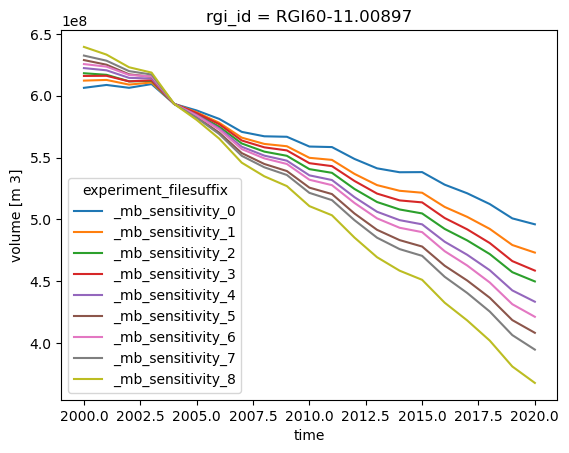

In [22]:
ds_all.sel(rgi_id=rgi_ids[0]).volume.plot(hue='experiment_filesuffix');

And now only the quantile distribution, compared to the default run:

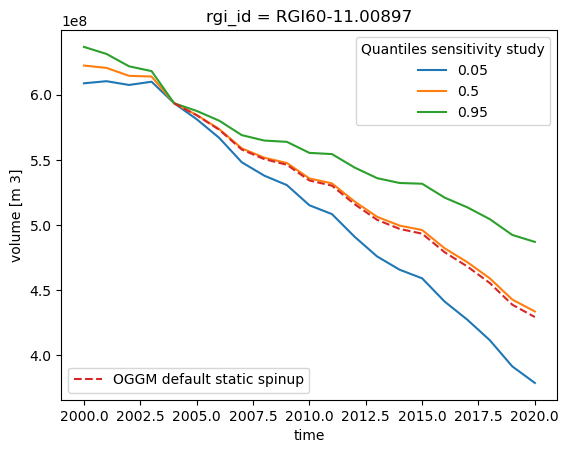

In [23]:
artists = ds_q.sel(rgi_id=rgi_ids[0]).volume.plot(hue='quantile')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('Quantiles sensitivity study');
line = ds_default.sel(rgi_id=rgi_ids[0]).volume.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='lower left')
ax.add_artist(leg1) 

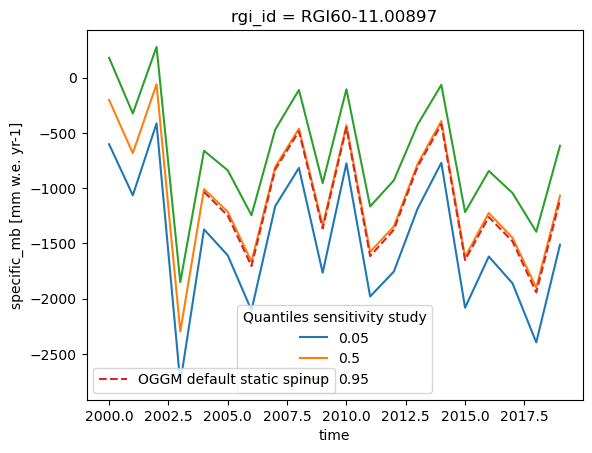

In [24]:
artists = ds_q.sel(rgi_id=rgi_ids[0]).specific_mb.plot(hue='quantile')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('Quantiles sensitivity study');
line = ds_default.sel(rgi_id=rgi_ids[0]).specific_mb.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='lower left')
ax.add_artist(leg1) 

The median of our experiments is very close to the default run: a good sign, since we perturbed the parameters symmetrically around their default values. Comparing your ensemble distribution to a default or control run is a useful sanity check for confirming that your perturbation design is balanced.

## Combining settings with observations sensitivity

Since we are using preprocessed directories from before v1.7, we first need to create a default `observations.yml` file manually. This file follows a similar logic to `settings.yml`, but is specifically intended to store the observations used during calibration and assimilation. Before v1.7, observations used during calibration were not stored in a central place. From v1.7 onwards, all tasks that use observations support an `observations_filesuffix` argument. If a task is designed for a specific dataset (e.g. `workflow.calibrate_inversion_from_consensus`, `massbalance.mb_calibration_from_hugonnet_mb`), the observations used for that glacier are automatically added to `observations.yml` when the task runs.

### The principle idea of `observations.yml`

Let's recreate `observations.yml` as it would look if the OGGM workflow had been run with v1.7. We use `gdir.create_new_observations`, which follows the same syntax as `gdir.create_new_settings` discussed above.

In [25]:
log = logging.getLogger(__name__)

@utils.entity_task(log)
def create_observations_for_backward_compatibility(gdir):
    """ Recreates observations.yml as it would have been created automatically
    if the OGGM workflow had been executed with v1.7 or later.
    """
    observation_data = {}

    # add RGI area; since we work in full calendar years, use the original RGI year + 1 as the timestamp
    observation_data['ref_area_m2'] = {
        'value': gdir.rgi_area_m2,
        'year': gdir.rgi_date + 1
    }
    
    # add the reference volume from regional calibration to the consensus estimate of Farinotti et al. (2019);
    # note: this is not the glacier-specific volume from the dataset, but the value
    # obtained from a regional calibration
    observation_data['ref_volume_m3'] = {
        'value': tasks.get_inversion_volume.unwrapped(gdir),
        'year': gdir.rgi_date + 1,
    }
    
    # add the reference geodetic mass balance from Hugonnet et al. (2021)
    ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir.rgi_id]
    ref_mb_df = ref_mb_df[ref_mb_df.period == cfg.PARAMS['geodetic_mb_period']]
    observation_data['ref_mb'] = {
        'period': cfg.PARAMS['geodetic_mb_period'],
        'err': ref_mb_df['err_dmdtda'].values[0] * 1000,
        'unit': 'kg m-2 yr-1',
        'value': ref_mb_df['dmdtda'].values[0]*1000,
    }

    # create the observations file using the same syntax as create_new_settings
    gdir.create_new_observations(filesuffix='',
                                 data=observation_data,
                                 ignore_existing=True,
                                 overwrite=True,
                                )

workflow.reset_multiprocessing()

In [26]:
workflow.execute_entity_task(create_observations_for_backward_compatibility, gdirs);

2026-04-03 09:53:48: oggm.workflow: Execute entity tasks [create_observations_for_backward_compatibility] on 2 glaciers
2026-04-03 09:53:49: __main__: (RGI60-11.00897) create_observations_for_backward_compatibility
2026-04-03 09:53:49: __main__: (RGI60-11.01450) create_observations_for_backward_compatibility


We can inspect the observations we just created using `gdir.read_observations`. It also accepts a `filesuffix` argument if you are working with multiple observation files:

In [27]:
gdirs[0].read_observations(filesuffix='')

{'filesuffix': '',
 'ref_area_m2': {'value': 8036000.0, 'year': 2004},
 'ref_mb': {'err': 171.8,
  'period': '2000-01-01_2020-01-01',
  'unit': 'kg m-2 yr-1',
  'value': -1100.3},
 'ref_volume_m3': {'value': 593426652.7574053, 'year': 2004}}

As a check, we can compare the reference mass balance value to what was stored in `mb_calib.json` in v1.6:

In [28]:
gdirs[0].read_json('mb_calib')['reference_mb']

-1100.3

By passing `observations_filesuffix` to an entity task, you can access the correct observations inside the task via `gdir.observations`. This works through the same decorator logic described for settings above ([see here](#define-your-own-entity_task)). Each observation name is standardized across OGGM tasks and currently supports `'ref_mb'`, `'ref_area_m2'`, and `'ref_volume_m3'`. For each observation, the actual value is stored under `'value'`, and the valid time under `'year'` or `'period'`. You can add any additional metadata that is useful, such as uncertainties or units. The observation file is designed to be extended incrementally as new observations become available. For distributed or more complex data, the idea is to store the relevant filepath in `observations.yml`, so that any analysis can quickly trace which observations were used in a given run.

### Define an entity task for perturbing settings and observations

We now define an entity task that creates matched settings and observations files for a workflow where we perturb `melt_f`, `ref_mb`, and `ref_volume_m3`. Both files use the same filesuffix so it is always clear which settings file was used together with which observations.

In [29]:
log = logging.getLogger(__name__)

@utils.entity_task(log)
def create_perturbed_settings_and_observations(gdir, new_filesuffix, melt_f_perturbation,
                                               ref_mb_perturbation, ref_volume_perturbation):
    """ Reads the default values of melt_f, ref_mb, and ref_volume_m3, adds a perturbation,
    and saves the result in new settings and observations files identified by new_filesuffix.
    """
    # read the default melt_f from the default settings file
    default_settings = gdir.read_settings(keys=['melt_f'],
                                          filesuffix='')

    # save the perturbed settings under new_filesuffix
    gdir.create_new_settings(filesuffix=new_filesuffix,
                             data={
                                 'melt_f': default_settings['melt_f'] + melt_f_perturbation,
                             },
                             parent_filesuffix='',
                             ignore_existing=True,
                             overwrite=True,
                            )

    # read the default observations from observations.yml
    default_observations = gdir.read_observations(keys=['ref_mb', 'ref_volume_m3'],
                                                  filesuffix='')

    # copy the original structure and apply the perturbation only to the values
    new_observations = default_observations
    new_observations.pop('filesuffix', None)  # remove the old filesuffix key
    new_observations['ref_mb']['value'] = default_observations['ref_mb']['value'] * ref_mb_perturbation
    new_observations['ref_volume_m3']['value'] = default_observations['ref_volume_m3']['value'] * ref_volume_perturbation

    # save the perturbed observations under new_filesuffix
    gdir.create_new_observations(filesuffix=new_filesuffix,
                                 data=new_observations,
                                 ignore_existing=True,
                                 overwrite=True,
                                )

workflow.reset_multiprocessing()

We again use `itertools.product` to generate all combinations of perturbations:

In [30]:
from itertools import product

# applied additively to the default melt_f
melt_f_perturbations = [-0.5, 0.5]

# applied multiplicatively to the default values, i.e. +/- 10%
ref_mb_perturbations = [0.9, 1.1]
ref_volume_perturbations = [0.9, 1.1]

# create all combinations of perturbations
all_combinations_advanced = list(product(melt_f_perturbations, ref_mb_perturbations, ref_volume_perturbations))

# common name for this set of experiments
advanced_experiment_name = '_mb_and_obs_sensitivity'

# container for all created filesuffixes
all_created_settings_advanced = []

for i, params in enumerate(all_combinations_advanced):
    # extract the individual perturbations
    melt_f_perturbation, ref_mb_perturbation, ref_volume_perturbation = params

    # define a unique filesuffix using a running index
    new_filesuffix = f"{advanced_experiment_name}_{i}"

    # execute the entity task for all glaciers
    workflow.execute_entity_task(create_perturbed_settings_and_observations, gdirs,
                                 new_filesuffix=new_filesuffix,
                                 melt_f_perturbation=melt_f_perturbation,
                                 ref_mb_perturbation=ref_mb_perturbation,
                                 ref_volume_perturbation=ref_volume_perturbation,
                                )

    # store the filesuffix for later reference
    all_created_settings_advanced.append(new_filesuffix)

2026-04-03 09:53:51: oggm.workflow: Execute entity tasks [create_perturbed_settings_and_observations] on 2 glaciers
2026-04-03 09:53:52: __main__: (RGI60-11.00897) create_perturbed_settings_and_observations
2026-04-03 09:53:52: __main__: (RGI60-11.01450) create_perturbed_settings_and_observations
2026-04-03 09:53:52: oggm.workflow: Execute entity tasks [create_perturbed_settings_and_observations] on 2 glaciers
2026-04-03 09:53:52: __main__: (RGI60-11.01450) create_perturbed_settings_and_observations
2026-04-03 09:53:52: __main__: (RGI60-11.00897) create_perturbed_settings_and_observations
2026-04-03 09:53:52: oggm.workflow: Execute entity tasks [create_perturbed_settings_and_observations] on 2 glaciers
2026-04-03 09:53:52: __main__: (RGI60-11.00897) create_perturbed_settings_and_observations
2026-04-03 09:53:52: __main__: (RGI60-11.01450) create_perturbed_settings_and_observations
2026-04-03 09:53:52: oggm.workflow: Execute entity tasks [create_perturbed_settings_and_observations] on 2

### Define your OGGM workflow combining multiple tasks

We now define our full OGGM workflow as an entity task. It consists of three steps: a fixed-geometry mass balance calibration matching a provided reference mass balance, a glacier bed inversion matching a provided reference volume, and a dynamic model run (without dynamic spinup).

In [31]:
log = logging.getLogger(__name__)

@utils.entity_task(log)
def my_oggm_workflow(gdir, experiment_filesuffix, observations_filesuffix=None):
    """ Defines a full OGGM workflow as an entity task. It consists of multiple
    tasks executed for each gdir and experiment.
    """

    # if no observations filesuffix is provided, use the same as the experiment filesuffix
    if observations_filesuffix is None:
        observations_filesuffix = experiment_filesuffix

    # fixed-geometry mass balance calibration: reads ref_mb from observations_filesuffix
    # and stores the resulting mass balance parameters in settings_filesuffix
    tasks.mb_calibration_from_scalar_mb(gdir,
                                        settings_filesuffix=experiment_filesuffix,
                                        observations_filesuffix=observations_filesuffix,
                                        calibrate_param1='prcp_fac',
                                        calibrate_param2='melt_f',
                                        calibrate_param3='temp_bias',
                                        overwrite_gdir=True,
                                       )

    # calculate the apparent mass balance using the newly calibrated parameters;
    # from here on we use the same filesuffix for all outputs to keep settings,
    # observations, and results traceable
    tasks.apparent_mb_from_any_mb(gdir,
                                  settings_filesuffix=experiment_filesuffix,
                                  input_filesuffix='',  # start from the inversion flowlines derived from the DEM and outline
                                  output_filesuffix=experiment_filesuffix,
                                 )

    # bed inversion calibrated to match ref_volume_m3 from observations_filesuffix
    workflow.calibrate_inversion_from_volume(
        [gdir],
        settings_filesuffix=experiment_filesuffix,
        observations_filesuffix=observations_filesuffix,
        input_filesuffix=experiment_filesuffix,  # use the inversion flowlines created by apparent_mb_from_any_mb
        output_filesuffix=experiment_filesuffix,
        apply_fs_on_mismatch=True,
        error_on_mismatch=True,  # set to False when running many glaciers where some may not converge
        filter_inversion_output=True,  # partially filters overdeepenings caused by the equilibrium
        # assumption for retreating glaciers (see Figure 5 of Maussion et al. 2019)
        add_to_log_file=False,
    )
    
    # initialise the dynamic flowlines for this experiment
    tasks.init_present_time_glacier(gdir,
                                    settings_filesuffix=experiment_filesuffix,
                                    input_filesuffix=experiment_filesuffix,
                                    output_filesuffix=experiment_filesuffix,
                                   )

    # run the dynamic model, saving all outputs under the same filesuffix
    tasks.run_from_climate_data(gdir,
                                settings_filesuffix=experiment_filesuffix,
                                model_flowlines_filesuffix=experiment_filesuffix,
                                output_filesuffix=experiment_filesuffix,
                                ye=2020,
                                fixed_geometry_spinup_yr=2000)

workflow.reset_multiprocessing()

### Run the custom OGGM workflow and combine outputs

As before, we define `(gdir, filesuffix)` pairs to make full use of multiprocessing ([see here](#execute-multiple-experiments-using-multiprocessing)).

In [32]:
all_experiments_advanced = []
for gdir in gdirs:
    for single_experiments_filesuffix in all_created_settings_advanced:
        all_experiments_advanced.append((gdir,
                                dict(experiment_filesuffix=single_experiments_filesuffix)
                               )
                              )

workflow.execute_entity_task(my_oggm_workflow, all_experiments_advanced);

2026-04-03 09:53:52: oggm.workflow: Execute entity tasks [my_oggm_workflow] on 16 glaciers
2026-04-03 09:53:54: __main__: (RGI60-11.00897) my_oggm_workflow
2026-04-03 09:53:54: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb_mb_and_obs_sensitivity_0
2026-04-03 09:53:54: oggm.core.massbalance: (RGI60-11.00897) apparent_mb_from_any_mb_mb_and_obs_sensitivity_0_mb_and_obs_sensitivity_0
2026-04-03 09:53:54: oggm.workflow: Applying global task calibrate_inversion_from_volume on 1 glaciers
2026-04-03 09:53:54: oggm.workflow: Volume estimate optimisation with A factor: 0.1 and fs: 0
2026-04-03 09:53:54: oggm.workflow: Applying global task inversion_tasks on 1 glaciers
2026-04-03 09:53:54: oggm.workflow: Execute entity tasks [prepare_for_inversion] on 1 glaciers
2026-04-03 09:53:54: oggm.core.inversion: (RGI60-11.00897) prepare_for_inversion_mb_and_obs_sensitivity_0_mb_and_obs_sensitivity_0
2026-04-03 09:53:54: oggm.workflow: Execute entity tasks [mass_conservation_inversi

We combine the outputs the same way as in the simple sensitivity study above ([see here](#combine-the-output-of-multiple-experiments)).

In [33]:
# container for individual experiment outputs
ds_all_advanced = []
for suffix in all_created_settings_advanced:
    ds_tmp = utils.compile_run_output(gdirs,
                                      input_filesuffix=suffix)
    ds_tmp.coords['experiment_filesuffix'] = suffix
    ds_tmp = ds_tmp.expand_dims('experiment_filesuffix')
    ds_all_advanced.append(ds_tmp)

ds_all_advanced = xr.combine_by_coords(ds_all_advanced, fill_value=np.nan, combine_attrs="override")

# add specific mass balance
add_specific_mb(ds_all_advanced)

# calculate quantiles across all experiments
ds_q_advanced = ds_all_advanced.quantile([0.05, 0.5, 0.95], dim=['experiment_filesuffix'])

2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:53:57: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:53:57: oggm.utils: Applyin

### Look at some results

Let's start by looking at the glacier volume across all experiments:

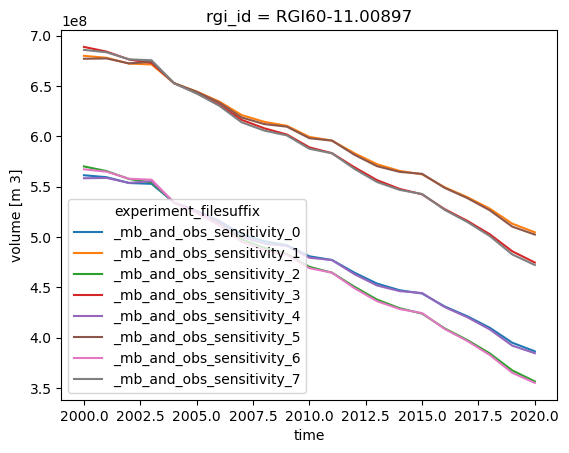

In [34]:
ds_all_advanced.sel(rgi_id=rgi_ids[0]).volume.plot(hue='experiment_filesuffix');

Runs sharing the same `ref_volume_m3` intersect at the RGI reference year, reflecting the two different reference volumes we used. Within each pair, the two distinct slopes correspond to the two different `ref_mb` values. The small remaining differences within each slope correspond to the two different perturbations of `melt_f`.

**Important:** when combining settings and observations perturbations, calibration steps may overwrite some settings values. It is therefore good practice to check the distribution of final settings after running your experiments. You can do this with `utils.compile_settings`:

In [35]:
df_settings_advanced = utils.compile_settings(gdirs[0],
                                              keys=['melt_f', 'prcp_fac', 'inversion_glen_a'],
                                              filesuffix=all_created_settings_advanced)

<Axes: >

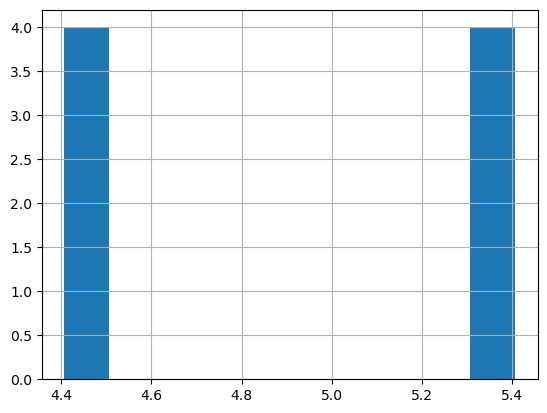

In [36]:
df_settings_advanced['melt_f'].hist()

In the `melt_f` distribution, the two prescribed values were never changed by a calibration step. However, this could happen depending on how the mass balance calibration is configured, in our workflow we set `calibrate_param2='melt_f'` (for more details on mass balance calibration see [this tutorial](massbalance_calibration.ipynb)).

<Axes: >

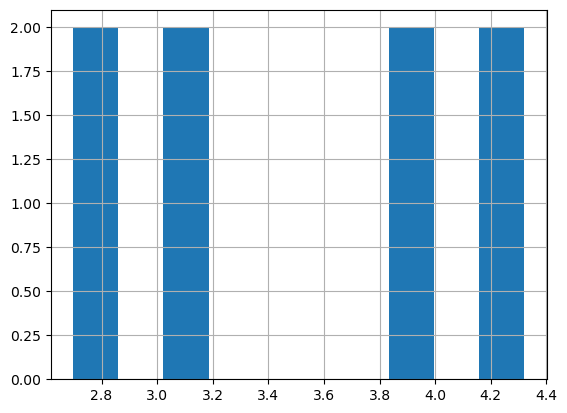

In [37]:
df_settings_advanced['prcp_fac'].hist()

The `prcp_fac` distribution shows four distinct values. This is because `prcp_fac` is determined by matching the mass balance to the provided `ref_mb` (two values) using the provided `melt_f` (also two values), resulting in four unique combinations.

<Axes: >

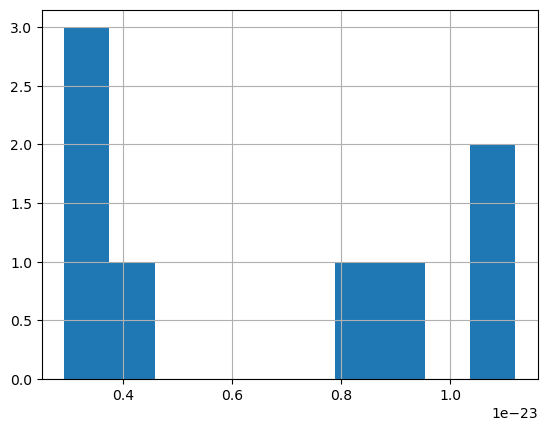

In [38]:
df_settings_advanced['inversion_glen_a'].hist()

The spread in `inversion_glen_a` reflects the interconnected nature of the OGGM workflow. This parameter is calibrated during inversion depending on both the target volume and the calibrated apparent mass balance, which is itself a combination of `ref_mb` and `melt_f`.

Let's also look at some plots:

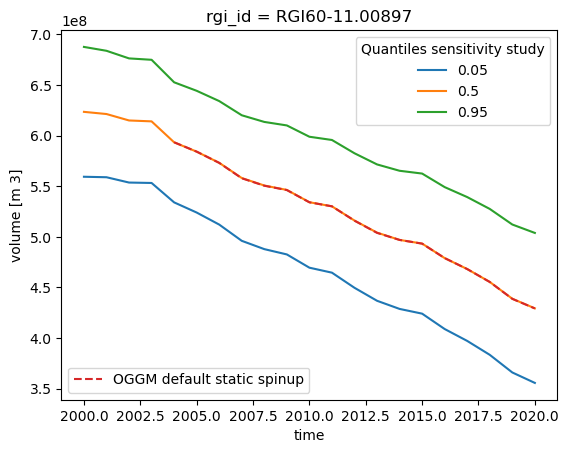

In [39]:
artists = ds_q_advanced.sel(rgi_id=rgi_ids[0]).volume.plot(hue='quantile')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('Quantiles sensitivity study');
line = ds_default.sel(rgi_id=rgi_ids[0]).volume.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='lower left')
ax.add_artist(leg1) 

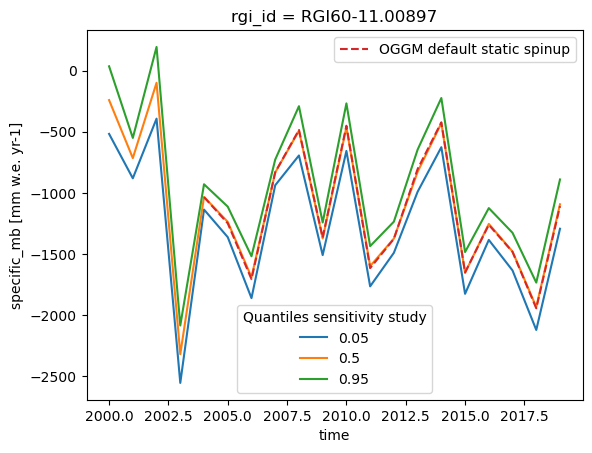

In [40]:
artists = ds_q_advanced.sel(rgi_id=rgi_ids[0]).specific_mb.plot(hue='quantile')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('Quantiles sensitivity study');
line = ds_default.sel(rgi_id=rgi_ids[0]).specific_mb.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='best')
ax.add_artist(leg1) 

Again, we see our median is very close to the OGGM default, which is an indication that our perturbation design is balanced.

## Advanced sensitivity study: perturbing global parameters (ice density)

So far we have perturbed glacier-specific parameters such as `melt_f` or `ref_mb`. Some parameters, however, are global. They apply to all glaciers equally and are stored in `cfg.PARAMS` rather than in `settings.yml`. A typical example is `ice_density`. The new settings system also supports perturbing global parameters: you can store an override value in a custom `settings.yml` file, and any task that reads the parameter through `gdir.settings` will use the overridden value for that experiment. This makes it possible to include global parameters in sensitivity studies using exactly the same workflow as for glacier-specific parameters. Here we demonstrate this for `ice_density`.

In [41]:
from itertools import product

ice_density_variations = [850, 900, 950]

density_experiment_name = '_ice_density_sensitivity'

all_created_settings_density = []

for i, new_ice_density in enumerate(ice_density_variations):
    new_filesuffix = f"{density_experiment_name}_{i}"

    for gdir in gdirs:
        gdir.create_new_settings(filesuffix=new_filesuffix,
                                 data={'ice_density': new_ice_density,},
                                 parent_filesuffix='',
                                 ignore_existing=True,
                                 overwrite=True,
                                )

    all_created_settings_density.append(new_filesuffix)

We now run the same OGGM workflow as before, using the default observations and the new settings files with different `ice_density` values:

In [42]:
all_experiments_density = []
for gdir in gdirs:
    for single_experiments_filesuffix in all_created_settings_density:
        all_experiments_density.append(
            (gdir, dict(
                experiment_filesuffix=single_experiments_filesuffix,
                observations_filesuffix='',  # use the default observations
            ))
        )

workflow.execute_entity_task(my_oggm_workflow, all_experiments_density);

2026-04-03 09:53:58: oggm.workflow: Execute entity tasks [my_oggm_workflow] on 6 glaciers
2026-04-03 09:54:00: __main__: (RGI60-11.00897) my_oggm_workflow
2026-04-03 09:54:00: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb_ice_density_sensitivity_0
2026-04-03 09:54:00: oggm.core.massbalance: (RGI60-11.00897) apparent_mb_from_any_mb_ice_density_sensitivity_0_ice_density_sensitivity_0
2026-04-03 09:54:00: __main__: (RGI60-11.00897) my_oggm_workflow
2026-04-03 09:54:00: __main__: (RGI60-11.00897) my_oggm_workflow
2026-04-03 09:54:00: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb_ice_density_sensitivity_2
2026-04-03 09:54:00: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb_ice_density_sensitivity_1
2026-04-03 09:54:00: oggm.workflow: Applying global task calibrate_inversion_from_volume on 1 glaciers
2026-04-03 09:54:00: oggm.workflow: Volume estimate optimisation with A factor: 0.1 and fs: 0
2026-04-03 09:54:00: oggm.work

Let's combine the outputs and look at the results:

In [43]:
# container for individual experiment outputs
ds_all_density = []
for suffix in all_created_settings_density:
    ds_tmp = utils.compile_run_output(gdirs,
                                      input_filesuffix=suffix)
    add_specific_mb(ds_tmp,
                    # use the correct ice density for each experiment
                    ice_density=gdirs[0].read_settings(['ice_density'], filesuffix=suffix)['ice_density'])
    ds_tmp.coords['experiment_filesuffix'] = suffix
    ds_tmp = ds_tmp.expand_dims('experiment_filesuffix')
    ds_all_density.append(ds_tmp)

ds_all_density = xr.combine_by_coords(ds_all_density, fill_value=np.nan, combine_attrs="override")

#add_specific_mb(ds_all_density)

#ds_q_density = ds_all_density.quantile([0.05, 0.5, 0.95], dim=['experiment_filesuffix'])

2026-04-03 09:54:01: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:54:01: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:54:01: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:54:01: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-03 09:54:01: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-03 09:54:01: oggm.utils: Applying compile_run_output on 2 gdirs.


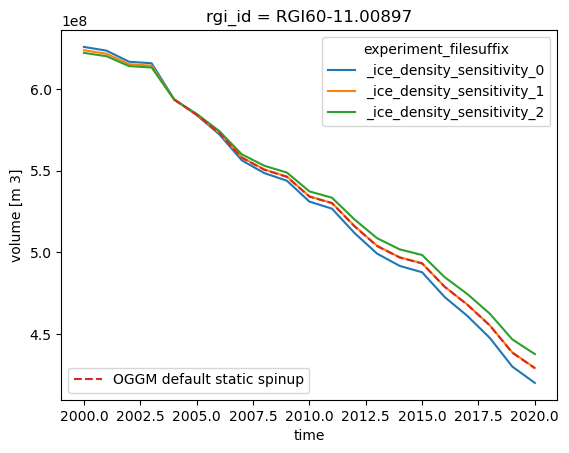

In [44]:
artists = ds_all_density.sel(rgi_id=rgi_ids[0]).volume.plot(hue='experiment_filesuffix')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('experiment_filesuffix');
line = ds_default.sel(rgi_id=rgi_ids[0]).volume.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='lower left')
ax.add_artist(leg1) 

Since we only varied `ice_density` in the settings and used the same default observations for all experiments, all runs start at the same volume at the RGI reference year. However, each run shows a different slope. Although all experiments were calibrated to match the same `ref_mb`, ice density enters the conversion between mass balance and volume, which leads to different volume trajectories even with identical mass balance parameters. We can confirm that the same mass balance parameters were used across all experiments:

In [45]:
utils.compile_settings(gdirs[0], ['melt_f', 'prcp_fac', 'temp_bias', 'ice_density'],
                       filesuffix=all_created_settings_density)

,rgi_id,filesuffix,melt_f,prcp_fac,temp_bias,ice_density
0,RGI60-11.00897,_ice_density_sensitivity_0,4.906857,3.509332,1.705036,850
1,RGI60-11.00897,_ice_density_sensitivity_1,4.906857,3.509332,1.705036,900
2,RGI60-11.00897,_ice_density_sensitivity_2,4.906857,3.509332,1.705036,950


However, the specific mass balance calculated from the dynamic run are all the same:

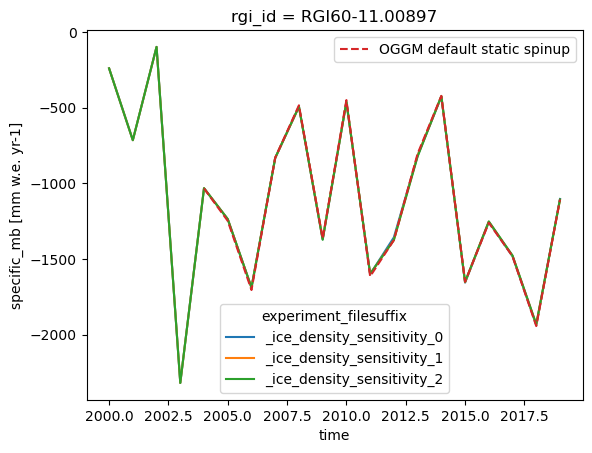

In [46]:
artists = ds_all_density.sel(rgi_id=rgi_ids[0]).specific_mb.plot(hue='experiment_filesuffix')
ax = artists[0].axes; leg1 = ax.get_legend(); leg1.set_title('experiment_filesuffix');
line = ds_default.sel(rgi_id=rgi_ids[0]).specific_mb.plot(linestyle='--')
ax.legend(handles=[line[0]], labels=['OGGM default static spinup'], loc='best')
ax.add_artist(leg1) 

## Summary

In this tutorial we introduced the new `settings.yml` and `observations.yml` files in OGGM v1.7 and showed how they enable systematic sensitivity studies. Here is a recap of the key concepts:

- **`settings.yml`** centralizes glacier-specific parameter storage and provides a nested lookup chain, falling back to `cfg.PARAMS` for global parameters and includes backwards compatibility for v1.6.
- **`observations.yml`** centralizes the observations used during calibration and assimilation, making it easy to trace which observations were used in any given run and to conduct observation perturbation experiments.
- **`entity_task` integration**: in any task that includes the arguments `settings_filesuffix` or `observations_filesuffix` the correct values can be accessed inside the task with `gdir.settings` or `gdir.observations`.
- **Global parameters** such as `ice_density` can be included in sensitivity studies by storing override values in `settings.yml`.